In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ['TAVILY_API_KEY'] = os.getenv("TAVILY_API_KEY")

In [7]:
from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(
        query: str, 
        max_results: int=5, 
        topic: Literal["sports", "news", "finance"] = "general", 
        include_raw_content: bool = False
    ):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        topic=topic,
        include_raw_content=include_raw_content,
    )

In [8]:
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:openai/gpt-oss-120b")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7f54df768650>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7f54df768200>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

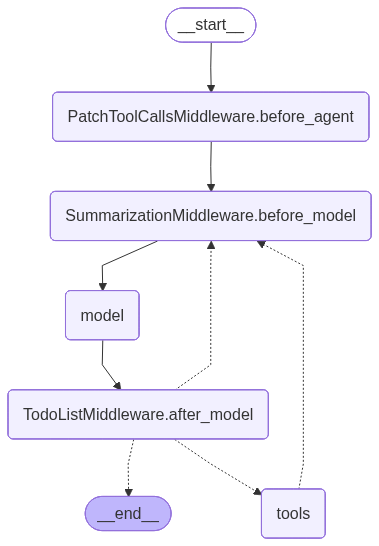

In [9]:
from deepagents import create_deep_agent

deepagent = create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher",
)
deepagent

In [10]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is Deepagent from langchain?"}]})
result

{'messages': [HumanMessage(content='What is Deepagent from langchain?', additional_kwargs={}, response_metadata={}, id='b1c347d1-4985-4160-9a61-464c06490721'),
  AIMessage(content='**DeepAgent** is a component in the LangChain ecosystem that provides a higher‑level, “agent‑like” abstraction for building autonomous AI applications.  \n\n### What it does\n- **Orchestrates multiple tools** (LLMs, APIs, custom functions, etc.) to accomplish a goal without a step‑by‑step prompt from the developer for each interaction.  \n- **Maintains state** across a conversation or task, allowing the system to remember past actions, results, and intermediate reasoning.  \n- **Implements a reasoning loop** (often called a “ReAct” loop) where the LLM can **think**, **act**, and **observe**:\n  1. **Think** – the LLM generates a plan or decides what tool to use next.  \n  2. **Act** – the system calls the selected tool (e.g., a web search, a database query, a calculator).  \n  3. **Observe** – the result of 

In [18]:
print(result["messages"][1].content)

**DeepAgent** is a component in the LangChain ecosystem that provides a higher‑level, “agent‑like” abstraction for building autonomous AI applications.  

### What it does
- **Orchestrates multiple tools** (LLMs, APIs, custom functions, etc.) to accomplish a goal without a step‑by‑step prompt from the developer for each interaction.  
- **Maintains state** across a conversation or task, allowing the system to remember past actions, results, and intermediate reasoning.  
- **Implements a reasoning loop** (often called a “ReAct” loop) where the LLM can **think**, **act**, and **observe**:
  1. **Think** – the LLM generates a plan or decides what tool to use next.  
  2. **Act** – the system calls the selected tool (e.g., a web search, a database query, a calculator).  
  3. **Observe** – the result of the tool call is fed back to the LLM, which can then revise its plan or produce a final answer.

### How it fits into LangChain
LangChain is a modular framework for building applications th